In [1]:
import torch
from torch.utils.data import DataLoader, Dataset

In [ ]:
class HiCDataset(Dataset):
    def __init__(self, data_files):
        self.data = []  # To store all sequences and HiC vectors
        
        # Load and process the data files
        for file in data_files:
            file_data = torch.load(file, weights_only=True)
            
            for data in file_data:
                ohe_sequence, hic_vector = data

                # Process the OHE sequence
                ohe_sequence = ohe_sequence.squeeze(0)  # Remove singleton dimension
                
                # Ensure the sequence has the correct shape
                assert ohe_sequence.shape[0] == 4, f"Expected 4 channels, but got {ohe_sequence.shape[0]}"
                assert len(ohe_sequence.shape) == 2, f"Expected 2D shape for sequence, but got {ohe_sequence.shape}"
                
                # Add processed pair to the data list
                self.data.append((ohe_sequence, hic_vector))
        
        print(f"Total sequences loaded: {len(self.data)}")
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Fetch the preprocessed (ohe_sequence, hic_vector) pair from memory
        ohe_sequence, hic_vector = self.data[idx]
        return ohe_sequence, hic_vector

In [ ]:
train_dataset = HiCDataset(['/scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_H1hESC/fold0_0.pt'])
# train_dataset = HiCDataset(['/scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Hsieh2019_mESC/fold0_0.pt'])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)

In [ ]:
# model_path = "/scratch1/smaruj/Akita_pytorch_models/tf_transferred/human_models/Krietenstein2019_H1hESC/Akita_v2_human_Krietenstein2019_H1hESC_model0.pth"
model_path = "./model_0_v2_finetuned_correctly.pt"

In [ ]:
from model import SeqNN

In [2]:
device = torch.device("cuda")

In [ ]:
from model_v2_compatible import SeqNN

In [ ]:
# model = torch.load(model_path, map_location=device)  # loads the entire SeqNN
# model.to(device)
# model.train()

In [ ]:
model = SeqNN()            # initialize your model architecture
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)      # load the saved weights
model.to(device)
model.train()                          # or .eval() if you’re evaluating

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [5]:
def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()

In [6]:
data = torch.load('/scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Bonev2017_NPC/fold0_0.pt')

In [13]:
vector_np = data[7][1].numpy()

In [14]:
matrix_np = from_upper_triu(vector_np, matrix_len=512, num_diags=2)

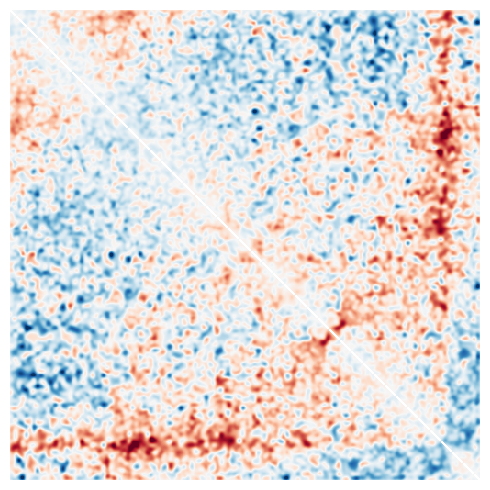

In [15]:
plot_map(matrix_np)

In [ ]:
import torch.nn.functional as F

In [ ]:
import schedulefree

In [ ]:
optimizer = schedulefree.AdamWScheduleFree(model.parameters(), lr=0.001, weight_decay=1.5e-5)

In [ ]:
model.train()
optimizer.train() 
optimizer.zero_grad()

train_loss = 0  # Initialize training loss
for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    output = model(data)
    
    print("data shape", data.shape)
    print("target shape", target.shape)
    print("output shape", output.shape)
    
    if torch.isnan(output).any():
        print("NaNs in output!")
    
    # if torch.any(torch.isnan(target)):
    # print("NaNs in target")
    
    # matrix_np = from_upper_triu(target.cpu().numpy(), matrix_len=448, num_diags=2)
    # plot_map(matrix_np)
    
    # Mask NaNs in target
    valid_mask = ~torch.isnan(target)
    loss = F.mse_loss(output[valid_mask], target[valid_mask])
    loss.backward()
    optimizer.step()
    
    # --- Gradient check ---
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(f"{name}: grad mean {param.grad.mean():.6f}, grad std {param.grad.std():.6f}")
        else:
            print(f"{name}: no grad")

    print("Loss:", loss.item())